<a href="https://colab.research.google.com/github/XMU-Zhoubo/topic3-pycwb-gw190521/blob/main/nootbooks/02_pixel_clustering_and_ff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 题目（三）第（2）问
## 连接到本地运行时
```
jupyter notebook --ip=0.0.0.0 --no-browser --port=8888 --NotebookApp.allow_origin='https://colab.research.google.com'
```

In [ ]:
user_parameters = """
analysis: "2G"
cfg_search: "r"

optim: False

###### network configuration ######
ifo: ["L1","H1"]
refIFO: "L1"

inRate: 16384
# lags
lagSize: 1
lagStep: 1.
lagOff: 0
lagMax: 0

# superlags
slagSize: 0 # number of super lags (simulation=1) - if slagSize=0 -> Standard Segments
slagMin: 0
slagMax: 0
slagOff: 0

# job
segLen: 1200
segMLS: 600
segTHR: 200
segEdge: 10

# frequency
fLow: 16.
fHigh: 1024.


levelR: 3
l_low: 4 # low frequency resolution level		// std (sthr = 2)
l_high: 10 # high frequency resolution level	// std (sthr = 8)

wdmXTalk: "wdmXTalk/OverlapCatalog16-1024.bin"

healpix: 7

###### cWB production thresholds & regulators ######

bpp: 0.001
subnet: 0.5
subcut: 0.0
netRHO: 5.5
# cedRHO: 5.0
netCC: 0.5
Acore: 1.7
Tgap: 0.2
Fgap: 128.0
delta: 0.5
cfg_gamma: -1.0
LOUD: 300

pattern: 5

iwindow: 30

nSky: 196608

# simulation
# simulation: None
nfactor: 1
"""

with open('user_parameters.yaml', 'w') as fp:
    fp.write(user_parameters)

In [ ]:
import os

import pycwb
from pycwb.config import Config
from pycwb.modules.logger import logger_init

if not os.environ.get('HOME_WAT_FILTERS'):
    pyburst_path = os.path.dirname(os.path.abspath(pycwb.__file__))
    os.environ['HOME_WAT_FILTERS'] = f"{os.path.abspath(pyburst_path)}/vendor"

logger_init()

config = Config('./user_parameters.yaml')

26-03-29 14:34:05 - logger_init - INFO - Logging initialized
26-03-29 14:34:05 - logger_init - INFO - Logging level: INFO
26-03-29 14:34:05 - logger_init - INFO - Logging file: None
26-03-29 14:34:06 - check_MRA_catalog - INFO - Checking MRA catalog
26-03-29 14:34:06 - load_MRA - INFO - Loading catalog of WDM cross-talk coefficients: /home/zhou/miniconda3/envs/pycwb/lib/python3.10/site-packages/pycwb/vendor/wdmXTalk/OverlapCatalog16-1024.bin


# 第（1）问已经完成的基础部分

In [ ]:
from pycwb.modules.read_data import read_from_catalog, read_from_online
from gwpy.timeseries import TimeSeries

import requests
from gwosc.locate import get_urls
t0 = 1242459857.4

data = []
for ifo in config.ifo:
  url = get_urls(ifo, t0, t0)[-1]

  print('Downloading: ' , url)
  fn = os.path.basename(url)
  with open(fn,'wb') as strainfile:
      straindata = requests.get(url)
      strainfile.write(straindata.content)

  strain = TimeSeries.read(fn,format='hdf5.gwosc')
  d = strain.crop(t0-150, t0+150)
  d_resampled = d.resample(2048)
  data.append(d_resampled)

Downloading:  https://gwosc.org/eventapi/json/GWTC-2.1-confident/GW190521_074359/v2/L-L1_GWOSC_4KHZ_R1-1242457810-4096.hdf5
Downloading:  https://gwosc.org/eventapi/json/GWTC-2.1-confident/GW190521_074359/v2/H-H1_GWOSC_4KHZ_R1-1242457810-4096.hdf5


### 经过 PycWB data_conditioning 后的时频图

26-03-29 14:38:04 - data_conditioning - INFO - Start data conditioning in parallel


/home/zhou/miniconda3/envs/pycwb/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


26-03-29 14:38:07 - data_conditioning - INFO - -------------------------------------------------------
26-03-29 14:38:07 - data_conditioning - INFO - Data Conditioning Time: 2.85 seconds
26-03-29 14:38:07 - data_conditioning - INFO - -------------------------------------------------------


((<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7c8b63e57dc0>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7c8b63e56680>),
 (<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7c8b63e57580>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7c8b63e54520>))

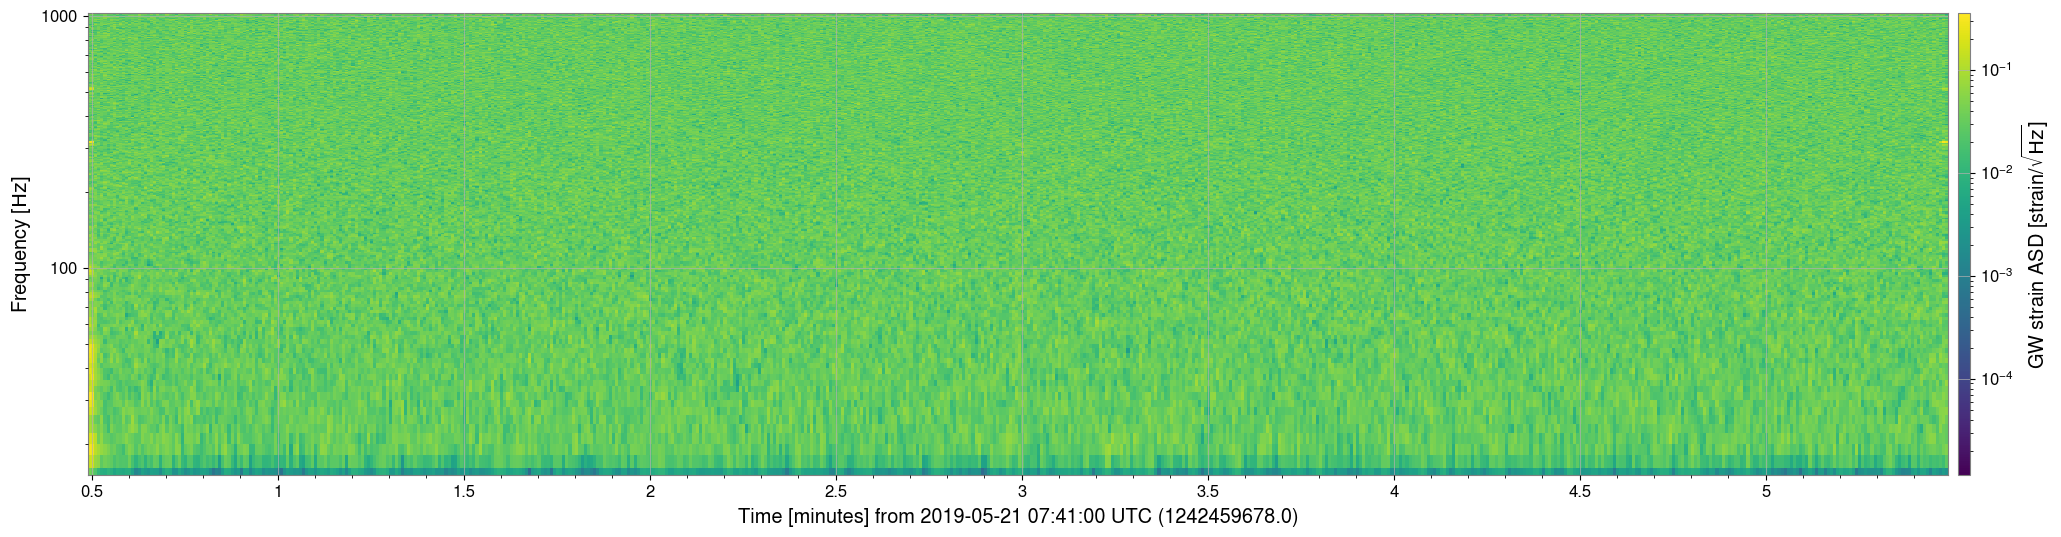

In [ ]:
from pycwb.modules.data_conditioning import data_conditioning
from pycwb.modules.plot import plot_spectrogram

strains, nRMS = data_conditioning(config, data)

# plot the spectrogram for L1
plt = plot_spectrogram(strains[0], gwpy_plot=True)
ax = plt.gca()
ax.set_ylim(15,1024)

strains, nRMS

In [ ]:
from pycwb.modules.coherence import coherence

# calculate coherence
fragment_clusters = coherence(config, strains, nRMS)

26-03-29 14:38:14 - coherence - INFO - Start coherence in parallel
26-03-29 14:38:21 - _coherence_single_res - INFO - level : 9	 rate(hz) : 4	 layers : 512	 df(hz) : 2.000000	 dt(ms) : 250.000000 
max energy in units of noise variance: 8.30387 
thresholds in units of noise variance: Eo=8.43924 Emax=16.8785 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |       10 |    136 
Coherence time for single level: 5.982127 s
26-03-29 14:38:21 - _coherence_single_res - INFO - level : 8	 rate(hz) : 8	 layers : 256	 df(hz) : 4.000000	 dt(ms) : 125.000000 
max energy in units of noise variance: 8.62635 
thresholds in units of noise variance: Eo=8.49005 Emax=16.9801 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |        5 |    153 
Coherence time for single level: 5.887740 s
26-03-29 14:38:21 - _coherence_single_res - INFO - level : 10	 rate(hz) : 2	 layers : 1024	 df(hz) : 1.000000	 dt(ms) : 500.000000 
max energy in units of noise variance: 7.95643 
thresholds in units of no

In [ ]:
from pycwb.modules.super_cluster import supercluster
from pycwb.types.network import Network

network = Network(config, strains, nRMS)

pwc_list = supercluster(config, network, fragment_clusters, strains)

26-03-29 14:38:27 - set_time_shift - INFO - lag step: 1.0
26-03-29 14:38:27 - set_time_shift - INFO - number of time lags: 1
26-03-29 14:38:28 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
26-03-29 14:38:28 - sparse_table_from_fragment_clusters - INFO - Sparse series time: 0.82 s
26-03-29 14:38:28 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
26-03-29 14:38:28 - supercluster - INFO - -> Processing lag=0 ...
26-03-29 14:38:28 - supercluster - INFO -    --------------------------------------------------
26-03-29 14:38:28 - supercluster - INFO -     coher clusters|pixels      :     67|982
26-03-29 14:38:28 - supercluster - INFO -     super clusters|pixels      :      7|519
26-03-29 14:38:28 - supercluster - INFO -    defrag clusters|pixels      :      7|519
26-03-29 14:38:28 - supercluster - INFO -    subnet clusters|pixels      :      1|370
26-03-29 14:38:28 - supercluster - INFO - Supercluster done
26-03

### PycWB 找到的 cluster 的时频稀疏图

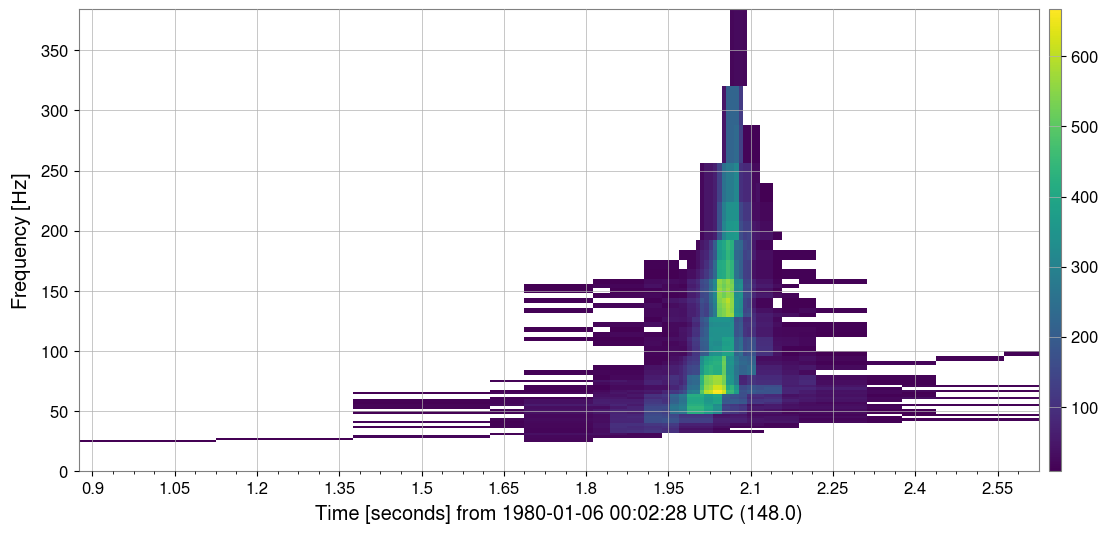

In [ ]:
# 移除 %matplotlib inline
from gwpy.spectrogram import Spectrogram
import matplotlib.pyplot as plt  # 显式导入 pyplot

for cluster in pwc_list[0].clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    # 用 fig 接收绘图对象，避免覆盖 plt
    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()
    fig.colorbar()  # 用 fig 调用 colorbar

plt.show()  # 本地环境显示图像的关键命令

In [ ]:
from pycwb.modules.likelihood import likelihood

events, clusters, skymap_statistics = likelihood(config, network, pwc_list)

26-03-29 14:38:32 - likelihood - INFO - -------------------------------------------------------
26-03-29 14:38:32 - likelihood - INFO - -> Processing 1 clusters in lag=0
26-03-29 14:38:32 - likelihood - INFO -    ----------------------------------------------------
26-03-29 14:38:37 - _likelihood - INFO - Selected core pixels: 1
26-03-29 14:38:37 - _likelihood - INFO -    cluster-id|pixels:     1|370
26-03-29 14:38:37 - _likelihood - INFO - 	 -> SELECTED !!!
26-03-29 14:38:38 - likelihood - INFO - -------------------------------------------------------
26-03-29 14:38:38 - likelihood - INFO - Total events: 1
26-03-29 14:38:38 - likelihood - INFO - Total time: 5.59 s
26-03-29 14:38:38 - likelihood - INFO - -------------------------------------------------------
mchirp_2g : 1 1 4.40e+01 3.025 150.061 0.000 1.038 



### 把 event 标到时频图上

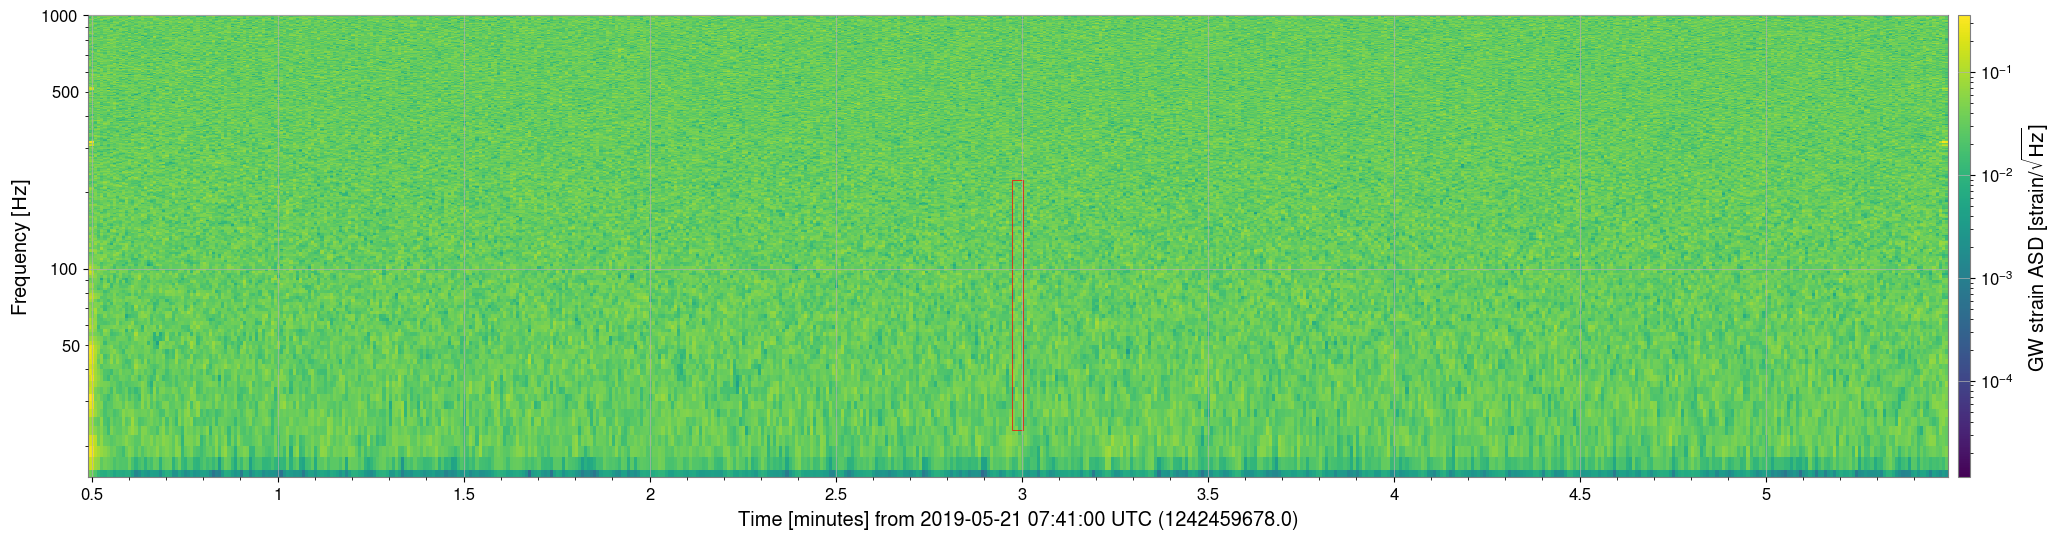

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】显式导入 pyplot
from pycwb.modules.plot import plot_event_on_spectrogram

fig = plot_event_on_spectrogram(strains[0], events)  # 【修改】用 fig 替代 plt 接收返回值
plt.show()  # 【新增】本地环境显示图像

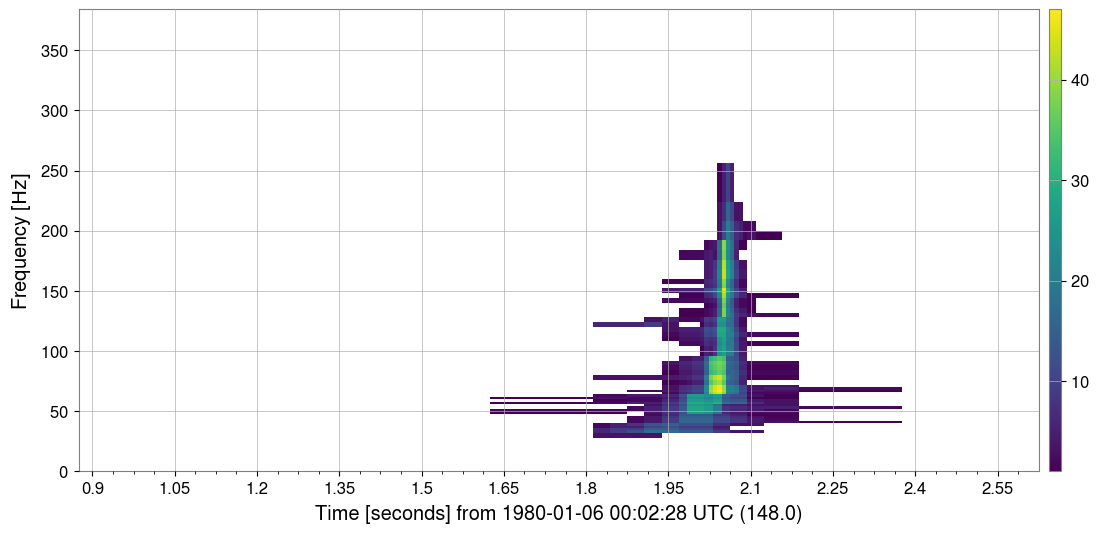

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()  # 【修改】plt→fig
    fig.colorbar()  # 【修改】plt→fig

plt.show()  # 【新增】


### 另一类 cluster map，能当对照图用

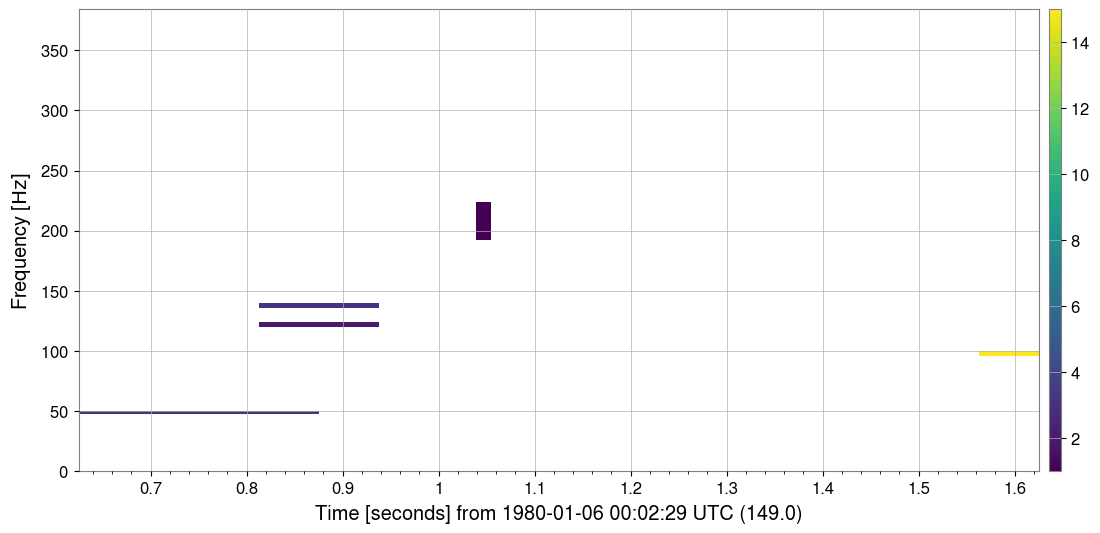

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("null")

    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()  # 【修改】plt→fig
    fig.colorbar()  # 【修改】plt→fig

plt.show()  # 【新增】


### PycWB 重构的时域波形

(149.0, 150.75)

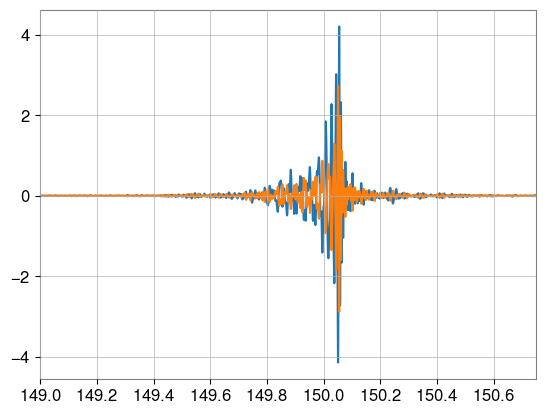

In [ ]:
from pycwb.modules.reconstruction import get_network_MRA_wave
from pycwb.modules.plot.waveform import plot_reconstructed_waveforms
from matplotlib import pyplot as plt

event = events[0]
cluster = clusters[0]
reconstructed_waves = get_network_MRA_wave(config, cluster, config.rateANA, config.nIFO, config.TDRate,
                                               'signal', 0, True)
for reconstructed_wave in reconstructed_waves:
  plt.plot(reconstructed_wave.sample_times, reconstructed_wave.data)
plt.xlim((event.left[0], event.left[0] + event.stop[0] - event.start[0]))

In [ ]:
events

[Event(nevent=1, ndim=2, run=0, rho=[15.651582717895508, np.float64(14.936389996515237), 0], netcc=[0, 0, 0], neted=[0, 0, 0, 0, 0], gnet=0.5748118162155151, anet=0.12673026323318481, inet=0.0, ecor=495.2447509765625, norm=6.891351222991943, ECOR=0.0, penalty=0, likelihood=665.4969482421875, factor=0.0, range=[0], chirp=[0, 44.00021743774414, 3.0248265266418457, 0.9875091910362244, 0.8859060406684875, 0.933883011341095], eBBH=[], usize=0.0, ifo_list=[], eventID=[1, 0], type=[1], name=[], log=[], rate=[0, 0], volume=[370, 149], size=[151, 150], gap=[0, 0], lag=[0.0, 0.0, 0.0, 0.0], slag=[0, 0, 0], strain=[np.float64(2.6069535980258567e-45)], phi=[279.84375, 0, 274.53102865302935, 257.6953125], theta=[75.83047778522995, 0, 14.169522214770055, 111.38194274902344], psi=[0.0], iota=[0.0], bp=[0.8409342104858897, -0.6128354419842369], bx=[-0.4339946475654604, 0.3741226278236298], time=[1242459857.4323273, 1242459857.4376523], gps=[1242459707.3999023, 1242459707.3999023], right=[149.25, 149.2

## 第（2）问
### 用于聚类的 STFT 时频图

fs = 2048.0 Hz
event window length = 1.60009765625 s


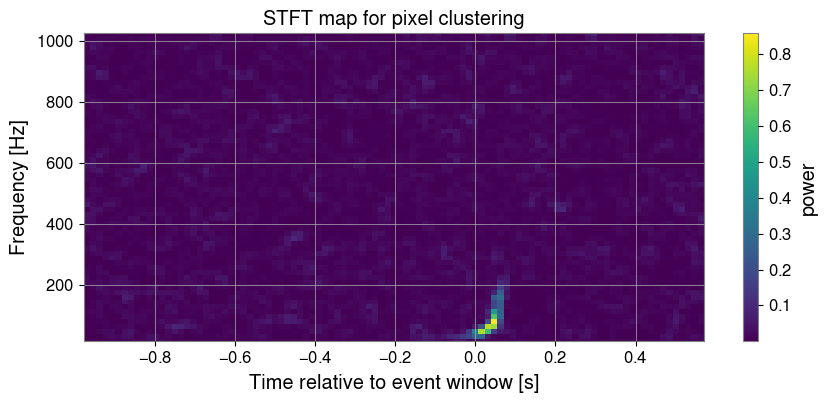

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, istft, correlate, resample
from sklearn.cluster import DBSCAN

def to_numpy(obj):
    if hasattr(obj, "value"):
        return np.asarray(obj.value, dtype=float).squeeze()
    if hasattr(obj, "data"):
        return np.asarray(obj.data, dtype=float).squeeze()
    return np.asarray(obj, dtype=float).squeeze()

def get_times(obj):
    if hasattr(obj, "times"):
        t = obj.times
        if hasattr(t, "value"):
            return np.asarray(t.value, dtype=float)
        return np.asarray(t, dtype=float)
    return None

def get_fs(obj, default=2048.0):
    if hasattr(obj, "sample_rate"):
        sr = obj.sample_rate
        if hasattr(sr, "value"):
            return float(sr.value)
        return float(sr)
    if hasattr(obj, "dt"):
        dt = obj.dt
        if hasattr(dt, "value"):
            dt = float(dt.value)
        return 1.0 / float(dt)
    return float(default)

def center_crop(sig, n):
    sig = np.asarray(sig, dtype=float)
    if len(sig) < n:
        pad = n - len(sig)
        left = pad // 2
        right = pad - left
        return np.pad(sig, (left, right))
    i = np.argmax(np.abs(sig))
    start = max(0, i - n // 2)
    end = start + n
    if end > len(sig):
        end = len(sig)
        start = end - n
    return sig[start:end]

# 用和你前面时频图一致的探测器：strains[0]
strain_obj = strains[0]
x = to_numpy(strain_obj)
t = get_times(strain_obj)
fs = get_fs(strain_obj, 2048.0)

if t is None:
    t = np.arange(len(x)) / fs

# 因为你前面 crop 了 t0±150 s，所以中心点就是事件附近
center = 0.5 * (t[0] + t[-1])
sel = (t >= center - 1.0) & (t <= center + 0.6)

x_evt = x[sel]
t_evt = t[sel] - center

print("fs =", fs, "Hz")
print("event window length =", len(x_evt) / fs, "s")

f, tt, Zxx = stft(
    x_evt,
    fs=fs,
    nperseg=128,
    noverlap=96,
    boundary=None,
    padded=False
)
power = np.nan_to_num(np.abs(Zxx) ** 2)

plt.figure(figsize=(10, 4))
plt.pcolormesh(tt + t_evt[0], f, power, shading="auto")
plt.ylim(15, 1024)
plt.xlabel("Time relative to event window [s]")
plt.ylabel("Frequency [Hz]")
plt.title("STFT map for pixel clustering")
plt.colorbar(label="power")
plt.show()

# 对高能像素做 DBSCAN 聚类
## 经过调参、比较后，效果较好的一组

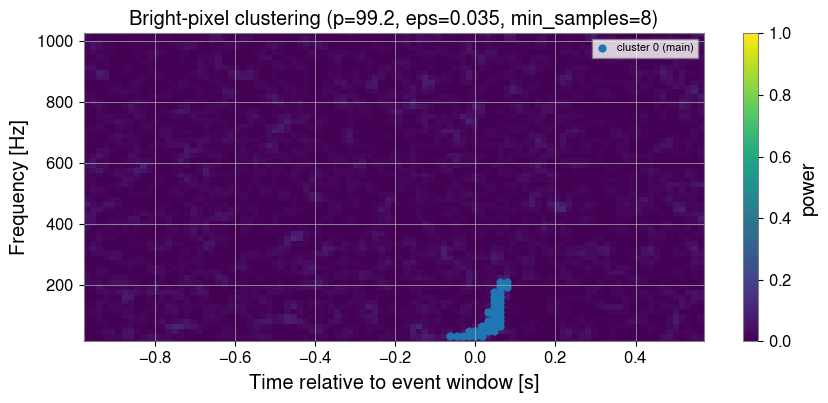

main_label = 0
main_cluster_size = 35


In [ ]:
percentile = 99.2
eps = 0.035
min_samples = 8

valid = power[np.isfinite(power) & (power > 0)]
thr = np.percentile(valid, percentile)

pts = np.argwhere(power >= thr)   # [freq_idx, time_idx]

pts_norm = pts / np.array(
    [max(power.shape[0] - 1, 1), max(power.shape[1] - 1, 1)],
    dtype=float
)

labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(pts_norm)

candidate_labels = [lab for lab in sorted(set(labels)) if lab != -1]
if not candidate_labels:
    raise RuntimeError("没有聚出有效 cluster。先试 percentile=99.0 或 eps=0.05")

main_label = max(candidate_labels, key=lambda lab: np.sum(labels == lab))
main_pts = pts[labels == main_label]

plt.figure(figsize=(10, 4))
plt.pcolormesh(tt + t_evt[0], f, power, shading="auto")

for lab in candidate_labels:
    p = pts[labels == lab]
    s = 24 if lab == main_label else 10
    a = 1.0 if lab == main_label else 0.45
    name = f"cluster {lab}" + (" (main)" if lab == main_label else "")
    plt.scatter(tt[p[:, 1]] + t_evt[0], f[p[:, 0]], s=s, alpha=a, label=name)

plt.ylim(15, 1024)
plt.xlabel("Time relative to event window [s]")
plt.ylabel("Frequency [Hz]")
plt.title(f"Bright-pixel clustering (p={percentile}, eps={eps}, min_samples={min_samples})")
plt.colorbar(label="power")
plt.legend(loc="upper right", fontsize=8)
plt.show()

print("main_label =", main_label)
print("main_cluster_size =", len(main_pts))



# 把主 cluster 逆回时域，并和 PycWB 重构波形比较

/tmp/ipykernel_6495/2022240630.py:6: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, h_cluster = istft(


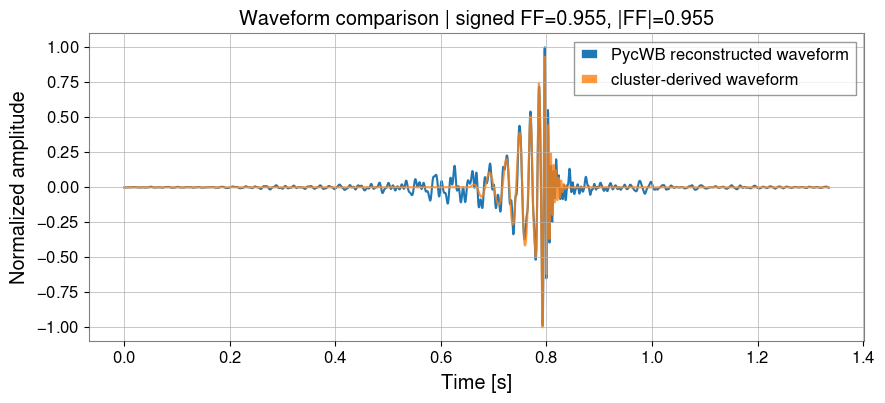

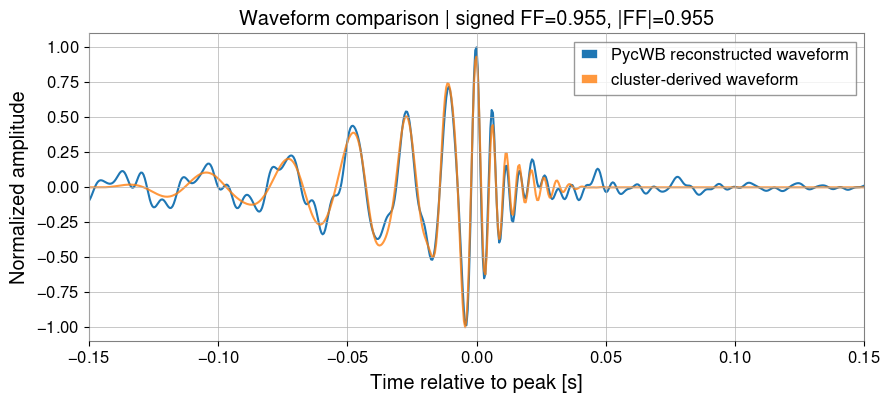

shift = 529 samples
signed FF = 0.9546869278265301
|FF| = 0.9546869278265301


In [ ]:
# 由主 cluster 反推出近似时域波形
mask = np.zeros_like(Zxx, dtype=bool)
mask[main_pts[:, 0], main_pts[:, 1]] = True
Z_main = np.where(mask, Zxx, 0.0)

_, h_cluster = istft(
    Z_main,
    fs=fs,
    nperseg=128,
    noverlap=96,
    input_onesided=True,
    boundary=None
)
h_cluster = np.real(h_cluster)

# 用 PycWB 的重构波形做比较
# 按你这份 notebook 的写法，通常 reconstructed_waves[0] 对应 strains[0]
rec_obj = reconstructed_waves[0]
h_rec = to_numpy(rec_obj)
fs_rec = get_fs(rec_obj, fs)

if abs(fs_rec - fs) > 1e-9:
    n_target = int(round(len(h_rec) * fs / fs_rec))
    h_rec = resample(h_rec, n_target)

# 裁成和 h_cluster 差不多长
n = len(h_cluster)
h_rec = center_crop(h_rec, n)

def align_by_xcorr(x, y):
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    corr = correlate(y, x, mode="full")
    shift = np.argmax(corr) - (len(x) - 1)
    if shift > 0:
        y = y[shift:]
    elif shift < 0:
        x = x[-shift:]
    m = min(len(x), len(y))
    return x[:m], y[:m], shift

def normalized_overlap(x, y):
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    den = np.linalg.norm(x) * np.linalg.norm(y)
    return 0.0 if den == 0 else float(np.dot(x, y) / den)

x_aligned, y_aligned, shift = align_by_xcorr(h_rec, h_cluster)
ff_signed = normalized_overlap(x_aligned, y_aligned)
ff_abs = abs(ff_signed)

x_plot = x_aligned / (np.max(np.abs(x_aligned)) + 1e-12)
y_plot = y_aligned / (np.max(np.abs(y_aligned)) + 1e-12)
t_plot = np.arange(len(x_plot)) / fs



plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, label="PycWB reconstructed waveform")
plt.plot(t_plot, y_plot, label="cluster-derived waveform", alpha=0.8)
plt.xlabel("Time [s]")
plt.ylabel("Normalized amplitude")
plt.title(f"Waveform comparison | signed FF={ff_signed:.3f}, |FF|={ff_abs:.3f}")
plt.legend()
plt.show()
#
peak = np.argmax(np.abs(x_plot))
t_plot = (np.arange(len(x_plot)) - peak) / fs

plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, label="PycWB reconstructed waveform")
plt.plot(t_plot, y_plot, label="cluster-derived waveform", alpha=0.8)
plt.xlim(-0.15, 0.15)
plt.xlabel("Time relative to peak [s]")
plt.ylabel("Normalized amplitude")
plt.title(f"Waveform comparison | signed FF={ff_signed:.3f}, |FF|={ff_abs:.3f}")
plt.legend()
plt.show()

#
print("shift =", shift, "samples")
print("signed FF =", ff_signed)
print("|FF| =", ff_abs)



# 一组试验用的参数（1）

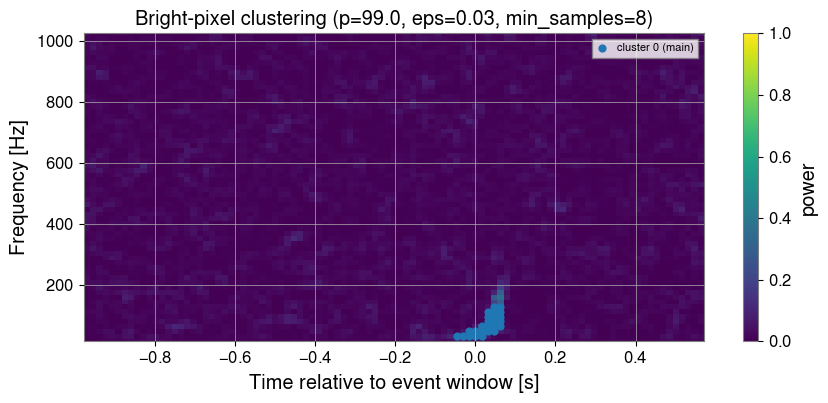

main_label = 0
main_cluster_size = 25


In [ ]:
percentile = 99.0
eps = 0.030
min_samples = 8

valid = power[np.isfinite(power) & (power > 0)]
thr = np.percentile(valid, percentile)

pts = np.argwhere(power >= thr)   # [freq_idx, time_idx]

pts_norm = pts / np.array(
    [max(power.shape[0] - 1, 1), max(power.shape[1] - 1, 1)],
    dtype=float
)

labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(pts_norm)

candidate_labels = [lab for lab in sorted(set(labels)) if lab != -1]
if not candidate_labels:
    raise RuntimeError("没有聚出有效 cluster。先试 percentile=99.0 或 eps=0.05")

main_label = max(candidate_labels, key=lambda lab: np.sum(labels == lab))
main_pts = pts[labels == main_label]

plt.figure(figsize=(10, 4))
plt.pcolormesh(tt + t_evt[0], f, power, shading="auto")

for lab in candidate_labels:
    p = pts[labels == lab]
    s = 24 if lab == main_label else 10
    a = 1.0 if lab == main_label else 0.45
    name = f"cluster {lab}" + (" (main)" if lab == main_label else "")
    plt.scatter(tt[p[:, 1]] + t_evt[0], f[p[:, 0]], s=s, alpha=a, label=name)

plt.ylim(15, 1024)
plt.xlabel("Time relative to event window [s]")
plt.ylabel("Frequency [Hz]")
plt.title(f"Bright-pixel clustering (p={percentile}, eps={eps}, min_samples={min_samples})")
plt.colorbar(label="power")
plt.legend(loc="upper right", fontsize=8)
plt.show()

print("main_label =", main_label)
print("main_cluster_size =", len(main_pts))



/tmp/ipykernel_6495/2022240630.py:6: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, h_cluster = istft(


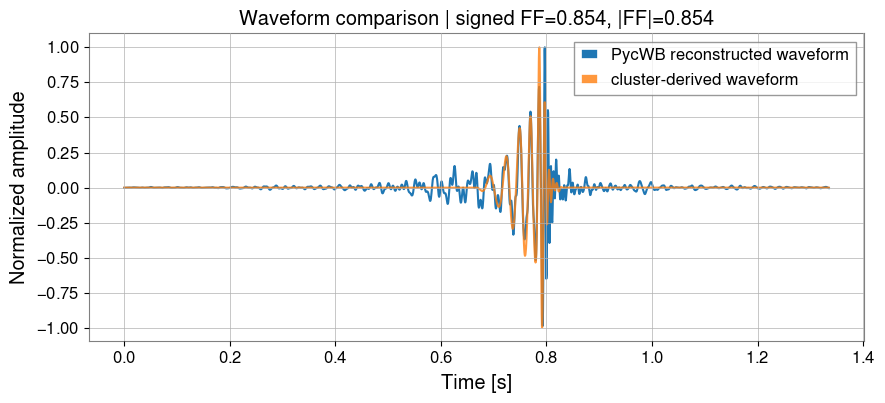

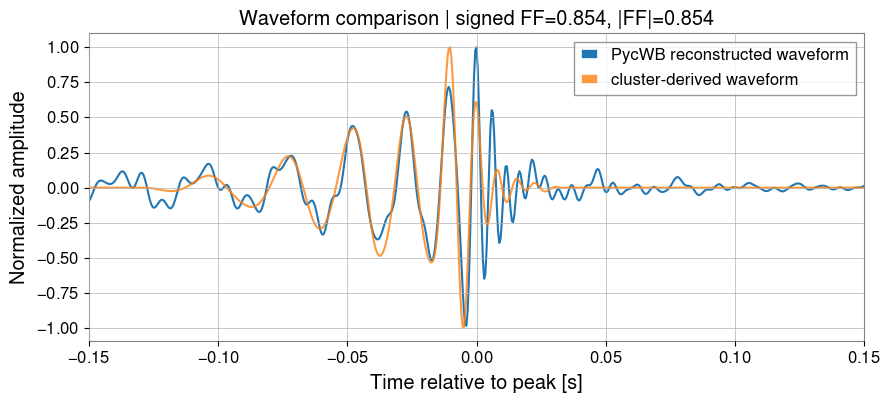

shift = 529 samples
signed FF = 0.8540583335371785
|FF| = 0.8540583335371785


In [ ]:
# 由主 cluster 反推出近似时域波形
mask = np.zeros_like(Zxx, dtype=bool)
mask[main_pts[:, 0], main_pts[:, 1]] = True
Z_main = np.where(mask, Zxx, 0.0)

_, h_cluster = istft(
    Z_main,
    fs=fs,
    nperseg=128,
    noverlap=96,
    input_onesided=True,
    boundary=None
)
h_cluster = np.real(h_cluster)

# 用 PycWB 的重构波形做比较
# 按你这份 notebook 的写法，通常 reconstructed_waves[0] 对应 strains[0]
rec_obj = reconstructed_waves[0]
h_rec = to_numpy(rec_obj)
fs_rec = get_fs(rec_obj, fs)

if abs(fs_rec - fs) > 1e-9:
    n_target = int(round(len(h_rec) * fs / fs_rec))
    h_rec = resample(h_rec, n_target)

# 裁成和 h_cluster 差不多长
n = len(h_cluster)
h_rec = center_crop(h_rec, n)

def align_by_xcorr(x, y):
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    corr = correlate(y, x, mode="full")
    shift = np.argmax(corr) - (len(x) - 1)
    if shift > 0:
        y = y[shift:]
    elif shift < 0:
        x = x[-shift:]
    m = min(len(x), len(y))
    return x[:m], y[:m], shift

def normalized_overlap(x, y):
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    den = np.linalg.norm(x) * np.linalg.norm(y)
    return 0.0 if den == 0 else float(np.dot(x, y) / den)

x_aligned, y_aligned, shift = align_by_xcorr(h_rec, h_cluster)
ff_signed = normalized_overlap(x_aligned, y_aligned)
ff_abs = abs(ff_signed)

x_plot = x_aligned / (np.max(np.abs(x_aligned)) + 1e-12)
y_plot = y_aligned / (np.max(np.abs(y_aligned)) + 1e-12)
t_plot = np.arange(len(x_plot)) / fs



plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, label="PycWB reconstructed waveform")
plt.plot(t_plot, y_plot, label="cluster-derived waveform", alpha=0.8)
plt.xlabel("Time [s]")
plt.ylabel("Normalized amplitude")
plt.title(f"Waveform comparison | signed FF={ff_signed:.3f}, |FF|={ff_abs:.3f}")
plt.legend()
plt.show()
#
peak = np.argmax(np.abs(x_plot))
t_plot = (np.arange(len(x_plot)) - peak) / fs

plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, label="PycWB reconstructed waveform")
plt.plot(t_plot, y_plot, label="cluster-derived waveform", alpha=0.8)
plt.xlim(-0.15, 0.15)
plt.xlabel("Time relative to peak [s]")
plt.ylabel("Normalized amplitude")
plt.title(f"Waveform comparison | signed FF={ff_signed:.3f}, |FF|={ff_abs:.3f}")
plt.legend()
plt.show()

#
print("shift =", shift, "samples")
print("signed FF =", ff_signed)
print("|FF| =", ff_abs)



# 一组试验用的参数（2）

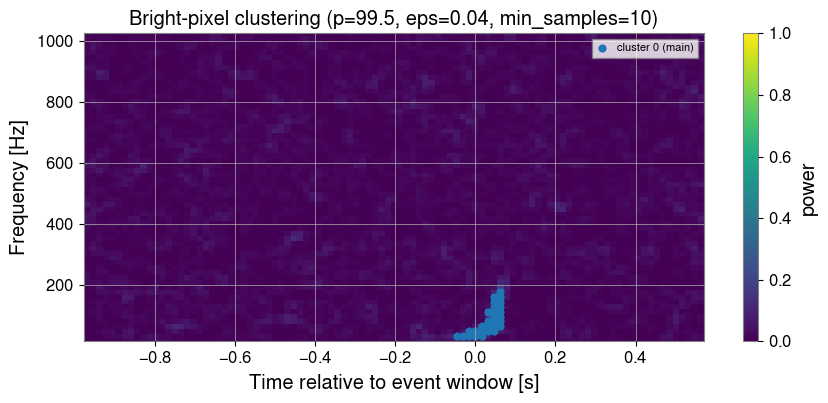

main_label = 0
main_cluster_size = 29


In [ ]:
percentile = 99.5
eps = 0.040
min_samples = 10

valid = power[np.isfinite(power) & (power > 0)]
thr = np.percentile(valid, percentile)

pts = np.argwhere(power >= thr)   # [freq_idx, time_idx]

pts_norm = pts / np.array(
    [max(power.shape[0] - 1, 1), max(power.shape[1] - 1, 1)],
    dtype=float
)

labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(pts_norm)

candidate_labels = [lab for lab in sorted(set(labels)) if lab != -1]
if not candidate_labels:
    raise RuntimeError("没有聚出有效 cluster。先试 percentile=99.0 或 eps=0.05")

main_label = max(candidate_labels, key=lambda lab: np.sum(labels == lab))
main_pts = pts[labels == main_label]

plt.figure(figsize=(10, 4))
plt.pcolormesh(tt + t_evt[0], f, power, shading="auto")

for lab in candidate_labels:
    p = pts[labels == lab]
    s = 24 if lab == main_label else 10
    a = 1.0 if lab == main_label else 0.45
    name = f"cluster {lab}" + (" (main)" if lab == main_label else "")
    plt.scatter(tt[p[:, 1]] + t_evt[0], f[p[:, 0]], s=s, alpha=a, label=name)

plt.ylim(15, 1024)
plt.xlabel("Time relative to event window [s]")
plt.ylabel("Frequency [Hz]")
plt.title(f"Bright-pixel clustering (p={percentile}, eps={eps}, min_samples={min_samples})")
plt.colorbar(label="power")
plt.legend(loc="upper right", fontsize=8)
plt.show()

print("main_label =", main_label)
print("main_cluster_size =", len(main_pts))



/tmp/ipykernel_6495/2022240630.py:6: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, h_cluster = istft(


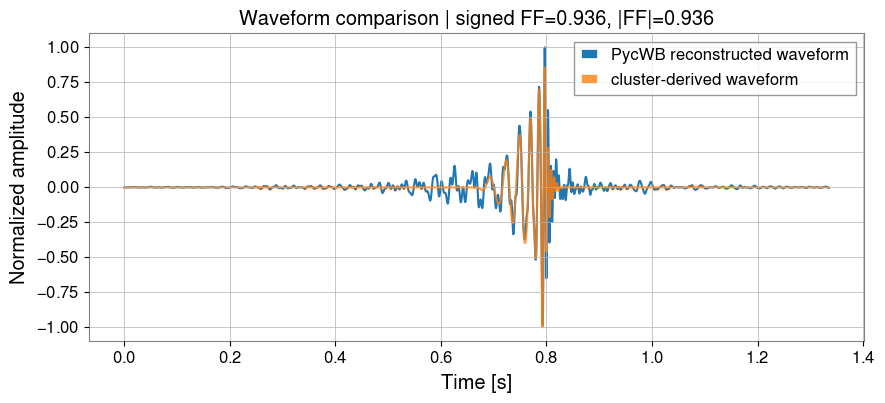

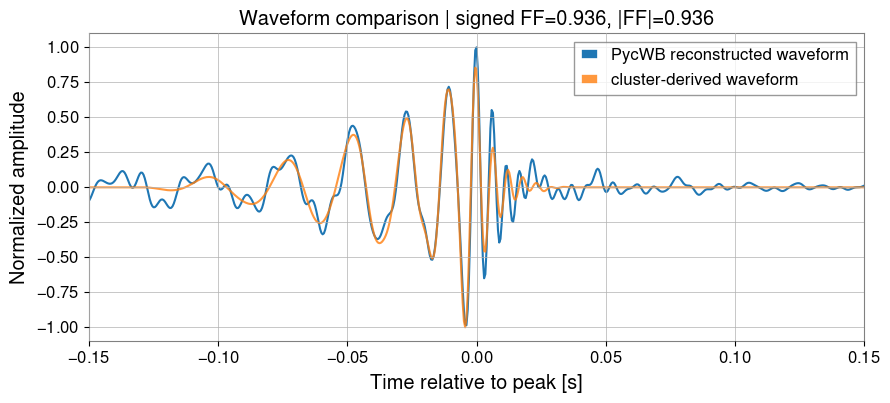

shift = 529 samples
signed FF = 0.9364837541103704
|FF| = 0.9364837541103704


In [ ]:
# 由主 cluster 反推出近似时域波形
mask = np.zeros_like(Zxx, dtype=bool)
mask[main_pts[:, 0], main_pts[:, 1]] = True
Z_main = np.where(mask, Zxx, 0.0)

_, h_cluster = istft(
    Z_main,
    fs=fs,
    nperseg=128,
    noverlap=96,
    input_onesided=True,
    boundary=None
)
h_cluster = np.real(h_cluster)

# 用 PycWB 的重构波形做比较
# 按你这份 notebook 的写法，通常 reconstructed_waves[0] 对应 strains[0]
rec_obj = reconstructed_waves[0]
h_rec = to_numpy(rec_obj)
fs_rec = get_fs(rec_obj, fs)

if abs(fs_rec - fs) > 1e-9:
    n_target = int(round(len(h_rec) * fs / fs_rec))
    h_rec = resample(h_rec, n_target)

# 裁成和 h_cluster 差不多长
n = len(h_cluster)
h_rec = center_crop(h_rec, n)

def align_by_xcorr(x, y):
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    corr = correlate(y, x, mode="full")
    shift = np.argmax(corr) - (len(x) - 1)
    if shift > 0:
        y = y[shift:]
    elif shift < 0:
        x = x[-shift:]
    m = min(len(x), len(y))
    return x[:m], y[:m], shift

def normalized_overlap(x, y):
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    den = np.linalg.norm(x) * np.linalg.norm(y)
    return 0.0 if den == 0 else float(np.dot(x, y) / den)

x_aligned, y_aligned, shift = align_by_xcorr(h_rec, h_cluster)
ff_signed = normalized_overlap(x_aligned, y_aligned)
ff_abs = abs(ff_signed)

x_plot = x_aligned / (np.max(np.abs(x_aligned)) + 1e-12)
y_plot = y_aligned / (np.max(np.abs(y_aligned)) + 1e-12)
t_plot = np.arange(len(x_plot)) / fs



plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, label="PycWB reconstructed waveform")
plt.plot(t_plot, y_plot, label="cluster-derived waveform", alpha=0.8)
plt.xlabel("Time [s]")
plt.ylabel("Normalized amplitude")
plt.title(f"Waveform comparison | signed FF={ff_signed:.3f}, |FF|={ff_abs:.3f}")
plt.legend()
plt.show()
#
peak = np.argmax(np.abs(x_plot))
t_plot = (np.arange(len(x_plot)) - peak) / fs

plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, label="PycWB reconstructed waveform")
plt.plot(t_plot, y_plot, label="cluster-derived waveform", alpha=0.8)
plt.xlim(-0.15, 0.15)
plt.xlabel("Time relative to peak [s]")
plt.ylabel("Normalized amplitude")
plt.title(f"Waveform comparison | signed FF={ff_signed:.3f}, |FF|={ff_abs:.3f}")
plt.legend()
plt.show()

#
print("shift =", shift, "samples")
print("signed FF =", ff_signed)
print("|FF| =", ff_abs)

